In [1]:
import numpy as np
import matplotlib.pyplot as plt

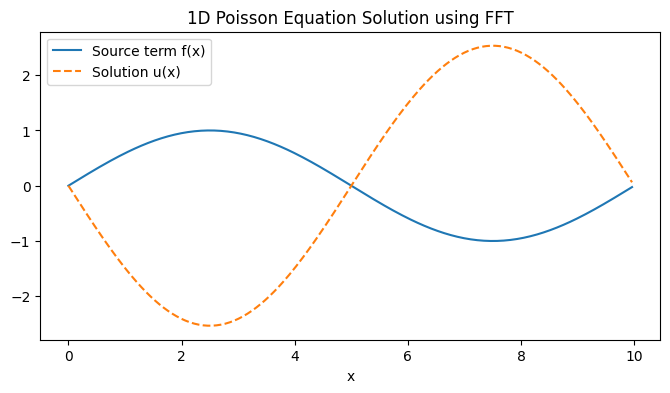

In [ ]:
# define the problem
L = 10.0
N = 256
f_fun = lambda x: np.sin(2*np.pi*x/L)
def u_analytic_fun(x):
    a = 2*np.pi/L
    return -(1/a)**2 * np.sin(a*x)

dx = L / N
x = np.linspace(0, L, N, endpoint=False)
f = f_fun(x)

# compute FT
f_hat = np.fft.fft(f)
k = 2*np.pi * np.fft.fftfreq(N, d=dx)

# avoid division by zero for k=0)
u_hat = np.zeros_like(f_hat)
mask = k != 0
u_hat[mask] = -f_hat[mask] / (k[mask] ** 2)

# inverse FT
u = np.fft.ifft(u_hat).real  # Take real part

# plotting
plt.figure(figsize=(8, 4))
plt.plot(x, f, label="Source term f(x)")
plt.plot(x, u, label="Solution u(x)", linestyle="dashed")
plt.xlabel("x")
plt.legend()
plt.title("1D Poisson Equation Solution using FFT")
plt.show()

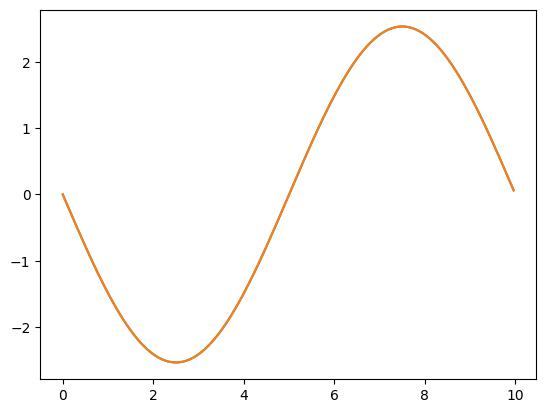

In [3]:
u_analytic = u_analytic_fun(x) 
plt.plot(x, u)
plt.plot(x, u_analytic)